# Project on Predicting Cotton Condition in Pakistan

In [4]:
import ee
import geemap

In [ ]:
ee.Authenticate()  # opens browser once, caches token locally
ee.Initialize(project="cottoncondition")

In [9]:
import geopandas as gpd

fields = gpd.read_file(r"C:\Users\donle\Desktop\Cotton Condition\QGIS Project\Vector Layers\cotton_in_pakistan.shp")
fields = fields.to_crs(epsg=4326)  # GEE expects WGS84


In [10]:

# bounding box covering all fields, as an ee.Geometry
minx, miny, maxx, maxy = fields.total_bounds
aoi = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

# fields themselves as an ee.FeatureCollection, for later per-field stats
fields_fc = geemap.geopandas_to_ee(fields)

In [11]:
# adjust to whichever season you're targeting:
# Kharif 2022 ~ Apr-Oct, Rabi 2021/22 ~ Nov 2021-Apr 2022
start_date = "2022-04-01"
end_date   = "2022-10-31"

In [12]:
def mask_s2_clouds(image):
    scl = image.select("SCL")
    # keep vegetation, bare soil, water; drop cloud/shadow/cirrus/snow classes
    mask = scl.remap([4, 5, 6, 11], [1, 1, 1, 1], 0)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
    .map(mask_s2_clouds)
)

In [13]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))  # pick one orbit to avoid mixing angles
)

In [14]:
months = ee.List.sequence(4, 10)  # April=4 ... October=10, matches Kharif window above

def monthly_composite(collection, year):
    def _make(m):
        m = ee.Number(m)
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1, "month")
        img = collection.filterDate(start, end).median()
        return img.set("system:time_start", start.millis(), "month", m)
    return ee.ImageCollection(months.map(_make))

s2_monthly = monthly_composite(s2, 2022)
s1_monthly = monthly_composite(s1, 2022)

## Plot NDVI?

In [17]:
def add_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)

s2_ndvi = s2.map(add_ndvi)
s2_ndvi_monthly = monthly_composite(s2_ndvi.select("NDVI"), 2022)

In [ ]:
# pick a field by row index (or filter fields_fc by an ID column you have)
field_id = 50
field_geom = geemap.geopandas_to_ee(fields.iloc[[field_id]]).geometry()

def extract_ndvi(image):
    stat = image.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=field_geom,
        scale=10,
        maxPixels=1e9,
    )
    return ee.Feature(None, {
        "month": image.get("month"),
        "ndvi": stat.get("NDVI"),
    })

ndvi_fc = ee.FeatureCollection(s2_ndvi_monthly.map(extract_ndvi))
ndvi_list = ndvi_fc.getInfo()["features"]


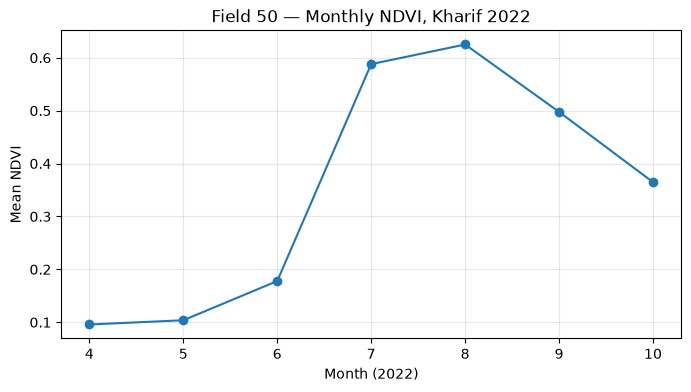

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

records = [f["properties"] for f in ndvi_list]
df = pd.DataFrame(records).sort_values("month")

plt.figure(figsize=(8, 4))
plt.plot(df["month"], df["ndvi"], marker="o")
plt.xlabel("Month (2022)")
plt.ylabel("Mean NDVI")
plt.title(f"Field {field_id} — Monthly NDVI, Kharif 2022")
plt.grid(True, alpha=0.3)
plt.show()

## All fields

In [35]:
fields = fields.reset_index(drop=True)
fields["field_id"] = fields.index
fields_fc = geemap.geopandas_to_ee(fields)

In [36]:
def extract_ndvi_all_fields(image_collection, feature_collection, scale=10):
    """
    For each image in image_collection (must have a 'month' property and an
    'NDVI' band), computes the per-field median NDVI for every field in
    feature_collection, using one reduceRegions call per image.

    Returns a pandas DataFrame with columns: field_id, month, ndvi
    """
    n = image_collection.size().getInfo()
    image_list = image_collection.toList(n)

    rows = []
    for i in range(n):
        image = ee.Image(image_list.get(i))
        month = image.get("month").getInfo()

        stats_fc = image.reduceRegions(
            collection=feature_collection,
            reducer=ee.Reducer.median(),
            scale=scale,
        )

        for feat in stats_fc.getInfo()["features"]:
            props = feat["properties"]
            rows.append({
                "field_id": props["field_id"],
                "month": month,
                "ndvi": props.get("NDVI"),
            })

    return pd.DataFrame(rows)

In [37]:
ndvi_df = extract_ndvi_all_fields(s2_ndvi_monthly, fields_fc)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

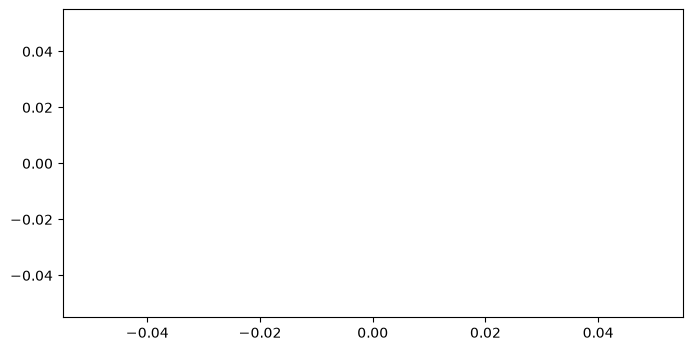

In [38]:
monthly_summary = (
    ndvi_df.groupby("month")["ndvi"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("month")
)

plt.figure(figsize=(8, 4))
plt.plot(monthly_summary["month"], monthly_summary["mean"], marker="o", label="Mean across fields")
plt.fill_between(
    monthly_summary["month"],
    monthly_summary["mean"] - monthly_summary["std"],
    monthly_summary["mean"] + monthly_summary["std"],
    alpha=0.2,
    label="±1 std across fields",
)
plt.xlabel("Month (2022)")
plt.ylabel("NDVI (median per field, then averaged)")
plt.title("Mean field-level NDVI across all fields, Kharif 2022")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()